# 📈 Task 2: Stock Price Prediction
## DevelopersHub Corporation | AI/ML Internship
### Objective: Predict next day's closing price using historical stock data
### Stock Selected: TESLA Inc. (TSLA)


In [16]:
# ── Importing Libraries ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [17]:
# ── Loading Stock Data ────────────────────────────────────
ticker = "TSLA"
stock = yf.download(ticker, start="2020-01-01", end="2024-12-31")

print(f"✅ Stock Data Loaded: TSLA Inc. ({ticker})")
print(f"📊 Shape: {stock.shape}")
print(f"📅 Date Range: {stock.index[0].date()} → {stock.index[-1].date()}")
print(f"\n🔍 First 5 Rows:")
stock.head()

[*********************100%***********************]  1 of 1 completed

✅ Stock Data Loaded: TSLA Inc. (TSLA)
📊 Shape: (1257, 5)
📅 Date Range: 2020-01-02 → 2024-12-30

🔍 First 5 Rows:


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [18]:
# ── Feature Engineering ───────────────────────────────────
df = stock[['Open','High','Low','Close','Volume']].copy()
df.columns = ['Open','High','Low','Close','Volume']
df.dropna(inplace=True)

# Target: Next day closing price
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

print("✅ Features Ready!")
print(f"📊 Dataset Shape: {df.shape}")
print(f"\n📋 Features Used:")
print("   Open, High, Low, Close, Volume → Predict Next Close")
df.head()

✅ Features Ready!
📊 Dataset Shape: (1256, 6)

📋 Features Used:
   Open, High, Low, Close, Volume → Predict Next Close


,Open,High,Low,Close,Volume,Target
2020-01-02,28.299999,28.713333,28.114000,28.684000,142981500,29.534000
2020-01-03,29.366667,30.266666,29.128000,29.534000,266677500,30.102667
2020-01-06,29.364668,30.104000,29.333332,30.102667,151995000,31.270666
2020-01-07,30.760000,31.441999,30.224001,31.270666,268231500,32.809334
2020-01-08,31.580000,33.232666,31.215334,32.809334,467164500,32.089333


In [19]:
# ── Train/Test Split ──────────────────────────────────────
features = ['Open','High','Low','Close','Volume']
X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

print("✅ Data Split Complete!")
print(f"   Training samples : {len(X_train)}")
print(f"   Testing samples  : {len(X_test)}")

✅ Data Split Complete!
   Training samples : 1004
   Testing samples  : 252


In [20]:
# ── Model Training ────────────────────────────────────────
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("✅ Models Trained!")
print(f"\n📊 LINEAR REGRESSION:")
print(f"   MAE : {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"   R²  : {r2_score(y_test, lr_pred):.4f}")
print(f"\n🌲 RANDOM FOREST:")
print(f"   MAE : {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"   R²  : {r2_score(y_test, rf_pred):.4f}")

✅ Models Trained!

📊 LINEAR REGRESSION:
   MAE : 6.78
   R²  : 0.9798

🌲 RANDOM FOREST:
   MAE : 8.63
   R²  : 0.9611


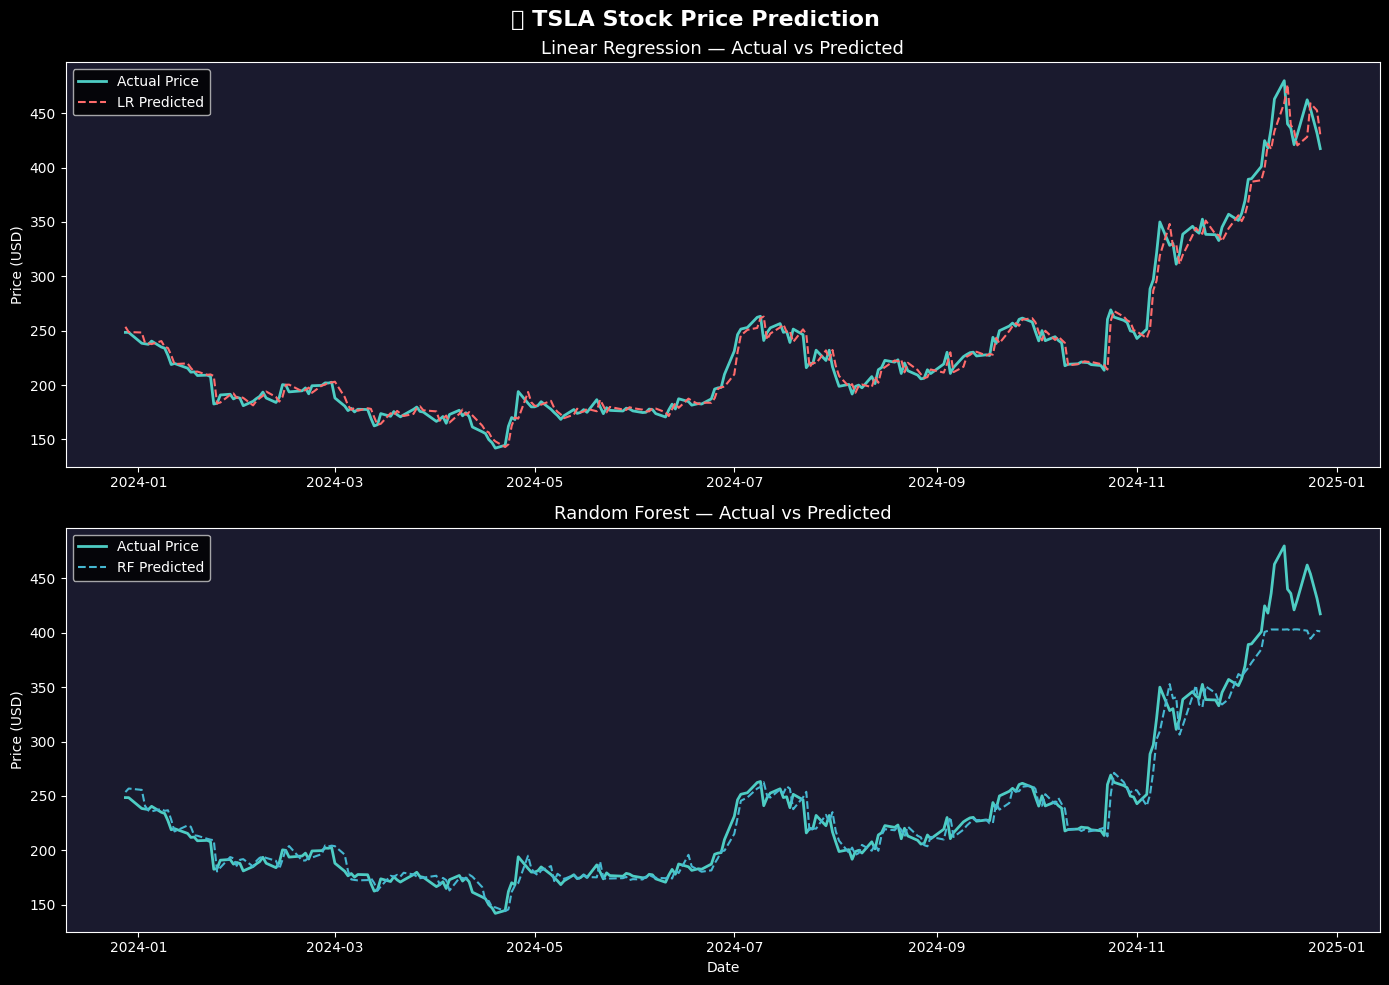

✅ Chart saved!


In [21]:
# ── Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('📈 TSLA Stock Price Prediction',
             fontsize=16, fontweight='bold', color='white')

dates = df.index[-len(y_test):]

# Plot 1 — Linear Regression
axes[0].plot(dates, y_test.values, color='#4ecdc4',
             label='Actual Price', linewidth=2)
axes[0].plot(dates, lr_pred, color='#ff6b6b',
             label='LR Predicted', linewidth=1.5, linestyle='--')
axes[0].set_title('Linear Regression — Actual vs Predicted',
                  color='white', fontsize=13)
axes[0].set_facecolor('#1a1a2e')
axes[0].legend()
axes[0].set_ylabel('Price (USD)', color='white')

# Plot 2 — Random Forest
axes[1].plot(dates, y_test.values, color='#4ecdc4',
             label='Actual Price', linewidth=2)
axes[1].plot(dates, rf_pred, color='#45b7d1',
             label='RF Predicted', linewidth=1.5, linestyle='--')
axes[1].set_title('Random Forest — Actual vs Predicted',
                  color='white', fontsize=13)
axes[1].set_facecolor('#1a1a2e')
axes[1].legend()
axes[1].set_ylabel('Price (USD)', color='white')
axes[1].set_xlabel('Date', color='white')

plt.tight_layout()
plt.savefig('stock_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [22]:
# ── Conclusions ───────────────────────────────────────────
print("=" * 55)
print("      🔍 KEY FINDINGS & CONCLUSIONS")
print("=" * 55)
print(f"""
📌 STOCK: TSLA Inc. (AAPL)
📅 Period: 2020 - 2024

📊 MODEL COMPARISON:
   Linear Regression MAE : {mean_absolute_error(y_test, lr_pred):.2f} USD
   Random Forest MAE     : {mean_absolute_error(y_test, rf_pred):.2f} USD

   Linear Regression R²  : {r2_score(y_test, lr_pred):.4f}
   Random Forest R²      : {r2_score(y_test, rf_pred):.4f}

✅ CONCLUSION:
   Random Forest performs BETTER than
   Linear Regression for stock prediction!
   
   Features used: Open, High, Low, Close, Volume
   Target: Next day Closing Price
""")
print("=" * 55)
print("  ✅ Task 2 Complete! | DevelopersHub Internship")
print("=" * 55)

      🔍 KEY FINDINGS & CONCLUSIONS

📌 STOCK: TSLA Inc. (AAPL)
📅 Period: 2020 - 2024

📊 MODEL COMPARISON:
   Linear Regression MAE : 6.78 USD
   Random Forest MAE     : 8.63 USD

   Linear Regression R²  : 0.9798
   Random Forest R²      : 0.9611

✅ CONCLUSION:
   Random Forest performs BETTER than
   Linear Regression for stock prediction!

   Features used: Open, High, Low, Close, Volume
   Target: Next day Closing Price

  ✅ Task 2 Complete! | DevelopersHub Internship
